# Code Refinement - Sequence to Sequence


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import seaborn as sns
from bertviz import head_view
# Evalutaion utils
from nltk.translate import bleu_score

SEED = 207
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.backends.cudnn.deterministic = True

## 1. Data

In [ ]:
splits = {'train': 'small/train-00000-of-00001.parquet', 'validation': 'small/validation-00000-of-00001.parquet', 'test': 'small/test-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/google/code_x_glue_cc_code_refinement/" + splits["train"])
val_df = pd.read_parquet("hf://datasets/google/code_x_glue_cc_code_refinement/" + splits["validation"])
test_df = pd.read_parquet("hf://datasets/google/code_x_glue_cc_code_refinement/" + splits["test"])

In [4]:
print("Number of samples per split : ")
print(f"Train : {len(df)}  | Val : {len(val_df)}  | Test : {len(test_df)}")

Number of samples per split : 
Train : 46680  | Val : 5835  | Test : 5835


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46680 entries, 0 to 46679
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      46680 non-null  int32
 1   buggy   46680 non-null  str  
 2   fixed   46680 non-null  str  
dtypes: int32(1), str(2)
memory usage: 12.8 MB


In [6]:
def token_edit_dist(a,b):
    a, b = a.strip().split(), b.strip().split()
    m, n = len(a), len(b)
    dp =[[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1):
        dp[i][0] = i
    for j in range(n+1):
        dp[0][j] = j
    for i in range(1,m+1):
        for j in range(1,n+1):
            if a[i-1] == b[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1+min(dp[i-1][j],dp[i][j-1],dp[i-1][j-1])
    return dp[m][n]
    
src_lens, tgt_lens, edits = [], [], []
for i,j in zip(df['buggy'],df['fixed']):
    src_lens.append(len(i.split()))
    tgt_lens.append(len(j.split()))
    edits.append(token_edit_dist(i, j))  

In [65]:
print(f"mean train source length: {np.mean(src_lens)} tokens")
print(f"mean train target length: {np.mean(tgt_lens)} tokens")
print(f"mean train edit distance: {np.mean(edits)} tokens")

mean train source length: 31.783954584404455 tokens
mean train target length: 28.987617823479006 tokens
mean train edit distance: 7.233526135389889 tokens


## 3. Tokenisation

In [ ]:
# Whitespace Tokeniser  
PAD, BOS, EOS, UNK = 0,1,2,3
all_tok = [k for i,j in zip(df['buggy'],df['fixed']) for k in i.split() + j.split()]
counter = Counter(all_tok)
VOCAB_A_SIZE = len(counter)
print(f'Unique tokens in training data: {VOCAB_A_SIZE}')
print(f'Most common: {counter.most_common(10)}')

Unique tokens in training data: 429
Most common: [('(', 379829), (')', 379829), (';', 189596), ('VAR_1', 150396), ('.', 146796), ('{', 121560), ('}', 121560), ('METHOD_1', 104217), (',', 85869), ('VAR_2', 80356)]


In [9]:
l_bug = [len(i.split()) for i in df['buggy']]
l_fix = [len(i.split()) for i in df['fixed']]
print(np.percentile(l_bug,99))
print(np.percentile(l_fix,99))

50.0
50.0


In [10]:
# Build the vocabulary
vocab = {'<PAD>':0, '<BOS>':1, '<EOS>':2, '<UNK>':3}
vocab.update({t:i+4 for i,t in enumerate(sorted(set(all_tok)))})
inv_vocab = {i:t for t,i in vocab.items()}
VOCAB_SIZE = len(vocab)
MAX_LEN = 50
def encode(text):
    ids = [BOS] + [vocab.get(t, UNK) for t in text.split()] + [EOS]
    return ids[:MAX_LEN] + [PAD] * max(0, MAX_LEN - len(ids))

def decode(ids):
    return ' '.join(inv_vocab.get(i, '?') for i in ids if i not in (PAD,BOS,EOS)) 


s = df['buggy'][0]
print(f"original: {s}")
print(f"encoded: {encode(s)}")
print(f"decoded: {decode(encode(s))}")

original: public java.lang.String METHOD_1 ( ) { return new TYPE_1 ( STRING_1 ) . format ( VAR_1 [ ( ( VAR_1 . length ) - 1 ) ] . getTime ( ) ) ; } 

encoded: [1, 357, 281, 79, 19, 20, 427, 366, 332, 106, 19, 91, 20, 30, 215, 19, 120, 137, 19, 19, 120, 30, 318, 20, 27, 38, 20, 138, 30, 232, 19, 20, 20, 43, 431, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
decoded: public java.lang.String METHOD_1 ( ) { return new TYPE_1 ( STRING_1 ) . format ( VAR_1 [ ( ( VAR_1 . length ) - 1 ) ] . getTime ( ) ) ; }


In [11]:
class CodeDataset(Dataset):
    def __init__(self,df):
        self.bug = torch.tensor([encode(i) for i in df['buggy']],dtype=torch.long)
        self.fix = torch.tensor([encode(i) for i in df['fixed']],dtype=torch.long)
    def __len__(self):
        return len(self.bug)
    def __getitem__(self, index):
        return self.bug[index], self.fix[index]

BATCH = 64
train_loader = DataLoader(CodeDataset(df), batch_size=BATCH, shuffle=True)
val_loader = DataLoader(CodeDataset(val_df),   batch_size=BATCH, shuffle=False)
test_loader = DataLoader(CodeDataset(test_df),  batch_size=BATCH, shuffle=False)

In [12]:
next(iter(train_loader))[0][0]

tensor([  1, 355, 281,  79,  19, 281, 120,  20, 427, 245, 192,  47,  19, 120,
         30, 318,  19,  20,  20,  27,  19, 129,  30, 318,  19,  20,  20,  43,
        366, 120,  30, 390,  19,  34,  26, 192,  20,  43, 431,   2,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0])

# 4. Evaluation Metrics and Training Utils

In [13]:
@torch.no_grad()
def compute_metrics(model, loader, decode_fn, max_len=100):

    model.eval()
    exact,bleu,edit = [],[],[]
    count = 0
    for x,y in loader:
        for i in range(x.shape[0]):
            if count >= max_len:
                break
            pred_ids = decode_fn(model, x[i:i+1].to(device))
            pred_str = decode(pred_ids)
            ref_str = decode(y[i].tolist())
            exact.append(pred_str.strip() == ref_str.strip())
            bleu.append(bleu_score.sentence_bleu([ref_str.split()], pred_str.split(), smoothing_function=bleu_score.SmoothingFunction().method1))
            edit.append(1-(token_edit_dist(pred_str,ref_str)/max(len(pred_str.split()),len(ref_str.split()))))
            count += 1
        if count >= max_len:
            break
    return {"exact":np.mean(exact), "bleu":np.mean(bleu), "edit":np.mean(edit)}


In [14]:
def train_epoch(model,loader,optimiser,criterion,device=device):
    model.train()
    tot_loss = 0
    for x,y in loader:
        x = x.to(device)
        y = y.to(device)
        optimiser.zero_grad()
        logits = model(x,y)
        loss = criterion(logits[:,1:].reshape(-1, VOCAB_SIZE), y[:, 1:].reshape(-1))
        loss.backward()
        optimiser.step()
        tot_loss += loss.item()
    return tot_loss / len(loader)

def train(model, train_loader, val_loader,
          epochs=30,
          lr=3e-4,
          crit = nn.CrossEntropyLoss,
          optim = torch.optim.Adam,
          verbose=True,
          name=None,
          **kwargs):
    model = model.to(device)
    optimiser = optim(model.parameters(),lr=lr, **kwargs)
    criterion = crit(ignore_index=PAD)
    best_val = np.inf
    history = []
    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, optimiser, criterion)

        model.eval()
        val = 0
        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device),y.to(device)
                logits = model(x,y) 
                val += criterion(logits[:,1:].reshape(-1,VOCAB_SIZE),y[:,1:].reshape(-1)).item()
        val /= len(val_loader)

        history.append({'epoch':epoch+1, 'train_loss':train_loss,'val_loss':val})
        if val < best_val:
            best_val  = val
            if name:
                torch.save(model.state_dict(),name)
            else:
                torch.save(model.state_dict(),f'best{model.__class__.__name__}.pt')
        if (epoch)%5 == 0 and verbose:
            print(f"Epoch {epoch+1} | Train : {train_loss} | Val : {val}")
    return history

@torch.no_grad()
def greedy_decode(model, src, max_len=MAX_LEN):
    model.eval()
    tokens = [BOS]

    if "RNN" in model.__class__.__name__:
        # RNN path: model.forward handles autoregressive decoding 
        model.tf = 0.0
        tgt = torch.full((1, max_len), PAD, dtype=torch.long, device=src.device)
        tgt[0, 0] = BOS
        for t in range(1, max_len):
            for i, tok in enumerate(tokens):
                tgt[0, i] = tok
            logits = model(src, tgt)
            nxt = logits[0, t].argmax().item()
            tokens.append(nxt)
            if nxt == EOS:
                break
        model.tf = 1.0
    else:
        # Transformer path: call encode/decode directly and read last position
        enc, enc_mask = model.encode(src)
        for _ in range(max_len - 1):
            tgt_in = torch.tensor([tokens], dtype=torch.long, device=src.device)
            logits, _ = model.decode(tgt_in, enc, enc_mask)
            nxt = logits[0, -1].argmax().item()  
            tokens.append(nxt)
            if nxt == EOS:
                break

    return tokens


## 5. Models

### 5.1 RNN (GRU Cells) Encoder-Decoder, No attention

In [16]:
D_MODEL = 128
RNN_LAYERS = 2

In [33]:

class RNNEncoder(nn.Module):
    def __init__(self, d_model=D_MODEL,layers=RNN_LAYERS):
        super().__init__()
        self.embed = nn.Embedding(VOCAB_SIZE, d_model, padding_idx=PAD)
        self.gru = nn.GRU(d_model,d_model,layers,batch_first=True,bidirectional=True)
        self.fc = nn.Linear(2*d_model,d_model)

    def forward(self, x):
        out, h = self.gru(self.embed(x))        # out: (B,seq,2d) , h: (2L,B,d)
        # concat the final layers forward and backward
        h_last = torch.tanh(self.fc(torch.cat([h[-2],h[-1]],-1))) # (B,d)
        return out, h_last

class RNNDecoder(nn.Module):
    def __init__(self, d_model=D_MODEL, layers=RNN_LAYERS):
        super().__init__()
        self.enc = RNNEncoder(d_model,layers)
        self.embed = nn.Embedding(VOCAB_SIZE, d_model, padding_idx=PAD)
        self.gru = nn.GRU(d_model,d_model,layers,batch_first=True)
        self.head = nn.Linear(d_model,VOCAB_SIZE)
        self.layers = layers
    def forward(self, x, y):
        batch,y_len = y.shape
        _, h = self.enc(x)   # h: (B,d)
        h = h.unsqueeze(0).repeat(self.layers,1,1) # (layers,B,d) as input hidden state for decoder gru
        # for the baseline I am using teacher forcing so the logits generation is parallelised
        dec_inp = y[:,:-1] # (B,t_len-1)
        embeddigns = self.embed(dec_inp) # (B,t_len-1,d_model)
        out,_ = self.gru(embeddigns,h)  # (B,t_len-1,d_model)
        logits = self.head(out)         # (B,t_len-1, VOCAB_SIZE)
        o = torch.zeros(batch,y_len,VOCAB_SIZE, device=x.device)
        o[:,1:,:] = logits              # Fill positions 1 to t_len-1
        return o   

In [17]:
print("RNN Encoder Decoder - No attention")
print('-'*60)
rnn_noattn =  RNNDecoder()
rnn_noattn_hist = train(rnn_noattn, train_loader, val_loader)
rnn_noattn.load_state_dict(torch.load("bestRNNDecoder.pt",weights_only=True))

RNN Encoder Decoder - No attention
------------------------------------------------------------
Epoch 1 | Train : 2.3109646188069695 | Val : 1.5506310333376345
Epoch 6 | Train : 0.8923075577167615 | Val : 0.883996281934821
Epoch 11 | Train : 0.7208793538073971 | Val : 0.7371074064918186
Epoch 16 | Train : 0.6336297043382305 | Val : 0.6777829877708269
Epoch 21 | Train : 0.5746605220314575 | Val : 0.6464509076398351
Epoch 26 | Train : 0.5298827211742532 | Val : 0.6256540346404781


<All keys matched successfully>

## 5.2 Bahdanau Attention Model - Bidirectional encoder  + MLP Attention score

In [30]:
class BahdanauAttention(nn.Module):
    def __init__(self, d_model=D_MODEL):
        super().__init__()
        self.Ws = nn.Linear(d_model, d_model, bias=False)
        self.Wh = nn.Linear(2*d_model, d_model, bias=False)
        self.v = nn.Linear(d_model, 1, bias=False)

    def forward(self, s, enc_out):                    # s: (B,d), enc_out: (B,S,2d)
        e = self.v(torch.tanh(self.Ws(s).unsqueeze(1) + self.Wh(enc_out))).squeeze(-1)  # (B,S)
        alpha = torch.softmax(e,dim=-1)              # (B,S)
        context = (alpha.unsqueeze(-1) * enc_out).sum(1)  # (B,2d)
        return context


class RNNAttention(nn.Module):
    def __init__(self, d_model=D_MODEL, layers=RNN_LAYERS, tf=1.0):
        super().__init__()
        self.enc = RNNEncoder(d_model, layers)
        self.attn = BahdanauAttention(d_model)
        self.embed = nn.Embedding(VOCAB_SIZE, d_model, padding_idx=PAD)
        # decoder input: token embed (d) + context (2d) -> concat = 3d
        self.gru = nn.GRU(3*d_model, d_model, layers, batch_first=True, dropout=0.2 if layers>1 else 0)
        self.head = nn.Linear(d_model, VOCAB_SIZE)
        self.layers = layers
        self.tf = tf

    def forward(self, src, tgt):
        batch, t_len = tgt.shape
        enc_out, h = self.enc(src)                    # enc_out: (B,S,2d), h: (B,d)
        h = h.unsqueeze(0).repeat(self.layers, 1, 1)  # (layers,B,d) as initial decoder hidden state
        out = torch.zeros(batch, t_len, VOCAB_SIZE, device=src.device)
        tok = tgt[:, 0:1]                             # (B,1) start with <BOS>

        for t in range(1, t_len):
            # attend: use top decoder layer's state h[-1] (B,d) over all encoder outputs
            context = self.attn(h[-1], enc_out)           # (B,2d)
            inp = torch.cat([self.embed(tok), context.unsqueeze(1)], dim=-1)  # (B,1, d+2d) = (B,1,3d)
            x, h = self.gru(inp, h)                   # x: (B,1,d), h: (layers,B,d)
            logits = self.head(x.squeeze(1))          # (B, VOCAB_SIZE)
            out[:, t] = logits
            # teacher forcing or use own prediction
            tok = tgt[:, t:t+1] if random.random() < self.tf else logits.argmax(-1, keepdim=True)
        return out

In [ ]:
print("RNN Encoder Decoder - Bahdanau attention")
print('-'*60)

rnn_attn_hist = train(rnn_attn, train_loader, val_loader)

RNN Encoder Decoder - Bahdanau attention
------------------------------------------------------------
Epoch 1 | Train : 2.304227715975618 | Val : 1.3743811094242593
Epoch 6 | Train : 0.451166018925301 | Val : 0.42328007907971094
Epoch 11 | Train : 0.3520540877972564 | Val : 0.3566868716607923
Epoch 16 | Train : 0.31127461531799133 | Val : 0.33676223845585534
Epoch 21 | Train : 0.2833398367240004 | Val : 0.326289262784564
Epoch 26 | Train : 0.26232898141423316 | Val : 0.32005789665424306


## 5.3 Transformer Encoder - Decoder

In [26]:
class SwiGLU(nn.Module):
    def forward(self, x):
        x1, x2 = x.chunk(2,dim=-1)
        return x1 * nn.functional.silu(x2)
class GEGLU(nn.Module):
    def forward(self, x):
        x1, x2 = x.chunk(2,dim=-1)
        return x1 * nn.functional.gelu(x2)

In [82]:
N_HEADS = 8
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=D_MODEL, n_heads=N_HEADS, causal=False):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.dk = d_model // n_heads
        self.causal = causal

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, q, k, v, mask=None):
        batch, seq_len_q, _ = q.shape
        seq_len_k = k.shape[1]
        H = self.n_heads
        dk = self.dk
        Q = self.W_q(q).view(batch, seq_len_q, H, dk).transpose(1, 2)   # (B, H, seq_len_q, dk)
        K = self.W_k(k).view(batch, seq_len_k, H, dk).transpose(1, 2)   # (B, H, seq_len_k, dk)
        V = self.W_v(v).view(batch, seq_len_k, H, dk).transpose(1, 2)   # (B, H, seq_len_k, dk)
        attn_scores = (Q @ K.transpose(-2,-1)) / (dk**0.5)  # (B, H, seq_len_q, seq_len_k)
        if self.causal:
            causal_mask = torch.triu(torch.ones(seq_len_q, seq_len_q, device=q.device), diagonal=1).bool() # (seq_len_q, seq_len_q) only for decoder selfattn
            attn_scores = attn_scores.masked_fill(causal_mask, float('-inf')) # (B, H, seq_len_q, seq_len_k)
        # padding mask
        if mask is not None:
            mask = mask.unsqueeze(1).unsqueeze(2) # (B, 1, 1, seq_len_k)
            attn_scores = attn_scores.masked_fill(mask, float('-inf')) # (B, H, seq_len_q, seq_len_k) 

        weights = torch.softmax(attn_scores, dim=-1)  # (B, H, seq_len_q, seq_len_k)
        out = weights @ V                             # (B, H, seq_len_q, dk)
        out = out.transpose(1,2).contiguous().view(batch,seq_len_q,-1)  # (B, seq_len_q, d_model)
        return self.W_o(out), weights                                   # (B, seq_len_q, d_model)


class EncBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, n_heads=N_HEADS, hidden=256, drop=0.2,activation=nn.ReLU):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads, causal=False)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        if activation == "swiglu" or activation =="geglu":
            act = SwiGLU() if activation == "swiglu" else GEGLU()
            self.ff = nn.Sequential(nn.Linear(d_model, hidden*2), act,nn.Dropout(drop), nn.Linear(hidden, d_model))
        else:
            act = {'relu': nn.ReLU(), 'silu': nn.SiLU(), 'gelu': nn.GELU()}.get(activation, nn.ReLU())
            self.ff = nn.Sequential(nn.Linear(d_model, hidden), act,nn.Dropout(drop), nn.Linear(hidden, d_model))
  
        self.drop = nn.Dropout(drop)
    def forward(self, x, mask=None):
        x_norm = self.ln1(x)                              #(B,seq_len,d_model)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm, mask)  #(B,seq_len,d_model)
        x = x + self.drop(attn_out)                       #(B,seq_len,d_model)
        x = x + self.drop(self.ff(self.ln2(x)))       
        return x


class DecBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, n_heads=N_HEADS, hidden=256,drop=0.1,activation=nn.ReLU):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, causal=True)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, causal=False)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.ln3 = nn.LayerNorm(d_model)
        if activation == "swiglu" or activation =="geglu":
            act = SwiGLU() if activation == "swiglu" else GEGLU()
            self.ff = nn.Sequential(nn.Linear(d_model, hidden*2), act,nn.Dropout(drop), nn.Linear(hidden, d_model))
        else:
            act = {'relu': nn.ReLU(), 'silu': nn.SiLU(), 'gelu': nn.GELU()}.get(activation, nn.ReLU())
            self.ff = nn.Sequential(nn.Linear(d_model, hidden), act,nn.Dropout(drop), nn.Linear(hidden, d_model))
        self.drop = nn.Dropout(drop)
    def forward(self, x, enc_out, enc_mask=None, tgt_mask=None):
        # x: (B, tgt_len, d_model), enc_out: (B, seq_len, d_model), enc_mask: (B, seq_len)
        # masked self-attention (causal)
        x_norm = self.ln1(x)
        attn_out, _ = self.self_attn(x_norm, x_norm, x_norm, tgt_mask)
        x = x + self.drop(attn_out)
        # cross-attention (no causal)
        cross_out, cw = self.cross_attn(self.ln2(x), enc_out, enc_out, enc_mask) # (B,tgt_len, d_model), (B, H, seq_len_q,seq_len_k)
        x = x + self.drop(cross_out)
        x = x + self.drop(self.ff(self.ln3(x)))
        return x, cw                #(B,tgt_len,d_model)


class SinPE(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()*(-np.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TransformerSeq2Seq(nn.Module):
    def __init__(self, d_model=D_MODEL, n_heads=N_HEADS, n_enc=2, n_dec=2, hidden=256,drop=0.1
                ,tie_embedding=False
                ,activation='relu'):
        super().__init__()
        self.src_emb = nn.Embedding(VOCAB_SIZE, d_model, padding_idx=PAD)
        self.tgt_emb = nn.Embedding(VOCAB_SIZE, d_model, padding_idx=PAD)
        if tie_embedding:
            self.tgt_emb.weight = self.src_emb.weight
        self.pe = SinPE(d_model)
        self.enc_blocks = nn.ModuleList([EncBlock(d_model, n_heads, hidden,drop=drop, activation=activation) for _ in range(n_enc)])
        self.dec_blocks = nn.ModuleList([DecBlock(d_model, n_heads, hidden, drop=drop,activation=activation) for _ in range(n_dec)])
        self.head = nn.Linear(d_model, VOCAB_SIZE)

    def encode(self, src):
        mask = (src == PAD)         # (B, seq_len)
        x = self.pe(self.src_emb(src))   #(B, seq_len, d_model)
        for blk in self.enc_blocks:
            x = blk(x, mask)    
        return x, mask                  # (B, seq_len, d_model), (B, seq_len)

    def decode(self, tgt, enc, enc_mask):
        tgt_pad_mask = (tgt == PAD)                # (B, tgt_len)
        x = self.pe(self.tgt_emb(tgt))  #(B, tgt_len, d_model)
        cross_attns = []
        for blk in self.dec_blocks:
            x, cw = blk(x, enc, enc_mask, tgt_pad_mask)        # (B, tgt_len, d_model), (B, H, seq_len_q, seq_len_k)
            cross_attns.append(cw)
        return self.head(x), cross_attns        # (B, tgt_len, VOCAB_SIZE)

    def forward(self, src, tgt):
        enc, enc_mask = self.encode(src)
        out, _ = self.decode(tgt[:,:-1], enc, enc_mask)  # shift right by dropping last so that no position sees itself in decode
        dummy = torch.zeros(tgt.size(0), 1, out.size(-1), device=tgt.device)
        return torch.cat([dummy, out], dim=1)               # pad col 0 so logits[:,1:] still aligns

In [99]:
print("Transformer Encoder-Decoder")
print('-'*60)
transformer = TransformerSeq2Seq(hidden=128,d_model=96,n_heads=4)
transformer_hist = train(transformer, train_loader, val_loader, epochs=30, lr=1e-3)


Transformer Encoder-Decoder
------------------------------------------------------------
Epoch 1 | Train : 1.2098542363676306 | Val : 0.7029022503158321
Epoch 6 | Train : 0.3502183096866085 | Val : 0.3335109981505767
Epoch 11 | Train : 0.2909188419784585 | Val : 0.3012112129641616
Epoch 16 | Train : 0.26460229944284647 | Val : 0.29004334885141125
Epoch 21 | Train : 0.247896609526791 | Val : 0.28640922677257785
Epoch 26 | Train : 0.2346822147091774 | Val : 0.2855817626999772


In [100]:
transformer.load_state_dict(torch.load("bestTransformerSeq2Seq.pt", weights_only=True))

<All keys matched successfully>

## 6. Results

In [101]:
all_metrics = {}
for name, model in [
    # ('RNN', rnn_noattn),
    # ('RNN Bahdanau', rnn_attn),
    ('Transformer', transformer), 
    ]:
    all_metrics[name] = compute_metrics(model.to(device), test_loader,lambda mod, src: greedy_decode(mod, src))

print(f'{"Model":20s} {"Exact":10s} {"BLEU4":10s} {"Edit":10s}')
print('-'*50)
for name, m in all_metrics.items():
    print(f'{name:20s} {m["exact"]:.4f} {m["bleu"]:.4f} {m["edit"]:.4f}')

Model                Exact      BLEU4      Edit      
--------------------------------------------------
Transformer          0.1100 0.7511 0.8123


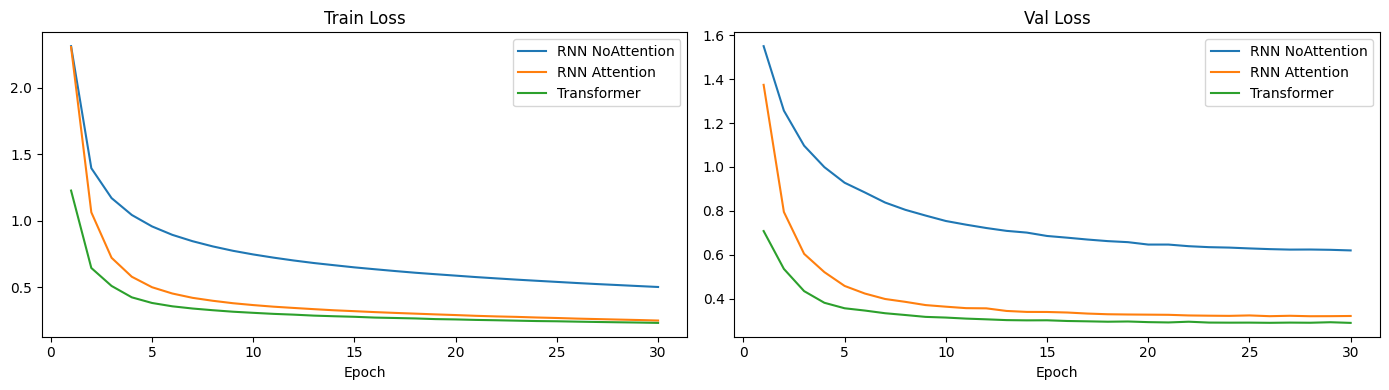

In [ ]:
fig, ax = plt.subplots(1, 2,figsize=(14, 4))
for hist, lbl in [(rnn_noattn_hist,'RNN NoAttention'),(rnn_attn_hist,'RNN Attention'),(transformer_hist,'Transformer')]:
    ax[0].plot([h['epoch'] for h in hist], [h['train_loss'] for h in hist], label=lbl)
    ax[1].plot([h['epoch'] for h in hist], [h['val_loss'] for h in hist], label=lbl)
for ax, t in zip(ax, ['Train Loss', 'Val Loss']):
    ax.set_title(t); ax.legend(); ax.set_xlabel('Epoch')
plt.tight_layout(); plt.show()

In [39]:
print("Greedy Decoding Prediction samples")
print('-'*60)
model = transformer
model_name = model.__class__.__name__
chk = 0
print(f"{model_name}")
print('-'*60)
ex = test_df.iloc[np.random.randint(1,5834)]
src = torch.tensor([encode(ex['buggy'])], dtype=torch.long, device=device)
with torch.no_grad():
    pred = decode(greedy_decode(model, src))
print(f"buggy: {ex['buggy']}")
print(f"fixed: {ex['fixed']}")
print(f"pred:{pred}")
print(f"match:{pred.strip() == ex['fixed'].strip()}")

Greedy Decoding Prediction samples
------------------------------------------------------------
TransformerSeq2Seq
------------------------------------------------------------
buggy: public void METHOD_1 ( java.lang.String VAR_1 ) { if ( ( METHOD_2 ( ) ) == 1 ) { VAR_2 = STRING_1 + ( VAR_1 . substring ( ( ( VAR_1 . length ( ) ) - INT_1 ) , INT_2 ) ) ; } } 

fixed: public java.lang.String METHOD_1 ( java.lang.String VAR_1 ) { if ( ( METHOD_2 ( ) ) == 1 ) { VAR_1 = STRING_1 + ( VAR_1 . substring ( ( ( VAR_1 . length ( ) ) - INT_1 ) , INT_2 ) ) ; } return VAR_1 ; } 

pred:public void METHOD_1 ( java.lang.String VAR_1 ) { if ( ( METHOD_2 ( ) ) == 1 ) { VAR_2 = STRING_1 + ( VAR_1 . substring ( ( ( VAR_1 . length ( ) ) - INT_1 ) , INT_2 ) ) ; } }
match:False


### 6.1 Teacher Forcing Ablation for RNN with Attention

In [ ]:
tf_results  = {}
tf_results[1.0] =compute_metrics(rnn_attn.to(device), test_loader,lambda model,src: greedy_decode(model, src))
for tf in [0.8]:
    print(f" TF = {tf}")
    print('-'*60)
    model = RNNAttention(tf=tf)
    # train(model,train_loader,val_loader,epochs=25,name=f'best_RNNAttention_tf{tf}.pt')
    tf_results[tf] = compute_metrics(model.to(device), test_loader,lambda model,src: greedy_decode(model, src))

print("Teacher forcing comparison:")
print('-'*60)
for tf, r in tf_results.items():
    print(f'  tf={tf:.1f} | exact: {r["exact"]:.4f} | bleu4: {r["bleu"]:.4f} | edit : {r["edit"]:.4f}')
    

 TF = 0.8
------------------------------------------------------------
 TF = 0.6
------------------------------------------------------------
Teacher forcing comparison:
------------------------------------------------------------
  tf=1.0 | exact: 0.1500 | bleu4: 0.7346 | edit : 0.8031
  tf=0.8 | exact: 0.0000 | bleu4: 0.0015 | edit : 0.0049
  tf=0.6 | exact: 0.0000 | bleu4: 0.0013 | edit : 0.0041


### 6.2 Decoding strategies


In [103]:
@torch.no_grad()
def beam_decode(model, src, max_len=MAX_LEN, k=5, alpha=0.6, temperature=1.0, top_p=1.0, rep_penalty=1.0):
    model.eval()
    enc, enc_mask = model.encode(src)                    # enc: (B, S, d), enc_mask: (B, S)
    beams, done = [([BOS], 0.0)], []

    for _ in range(max_len-1):
        cands = []
        for seq, score in beams:
            if seq[-1] == EOS:
                done.append((seq, score))
                continue
            tgt_in = torch.tensor([seq], dtype=torch.long, device=src.device)
            logits, _ = model.decode(tgt_in, enc, enc_mask)
            logits = logits[0, -1].float()               # (VOCAB,)
            # repetition penalty on last 20 tokens
            if rep_penalty != 1.0:
                for tok in set(seq[-20:]):
                    if tok not in [BOS,EOS,PAD]:
                        logits[tok] /= rep_penalty
            # temperature
            if temperature == 0:
                best_token = logits.argmax().item()
                cands.append((seq+[best_token],score))
                continue
            else:
                logits = logits / temperature 
                # top-p (nucleus) filtering
                if top_p < 1.0:
                    sorted_logits, sorted_idx = torch.sort(logits, descending=True)
                    probs = torch.softmax(sorted_logits, dim=-1)
                    remove = probs.cumsum(dim=-1) - probs > top_p
                    sorted_logits[remove] = float('-inf')
                    logits[sorted_idx] = sorted_logits
                lp = torch.log_softmax(logits, dim=-1)
                # top-k candidates - returns the log prob scores and indices
                for v, tok in zip(*lp.topk(k)):
                    cands.append((seq + [tok.item()], score + v.item()))
        if not cands:
            break
        cands.sort(key=lambda x: x[1], reverse=True)
        beams = cands[:k]
    done.extend(beams)
    best = max(done, key=lambda x: x[1] / (len(x[0]) ** alpha))[0]
    return best

beam_results = {}
for k in [1, 3, 5, 10]:
    def decode_fn(model, src, k=k):
        return beam_decode(model, src, k=k, temperature=0.8, top_p=0.95, rep_penalty=1.1)
    beam_results[k] = compute_metrics(transformer.to(device), test_loader, decode_fn)
    r = beam_results[k]
    print(f'beam={k} | exact: {r["exact"]:.4f} | bleu: {r["bleu"]:.4f}')

beam=1 | exact: 0.1100 | bleu: 0.7381
beam=3 | exact: 0.1100 | bleu: 0.7522
beam=5 | exact: 0.1100 | bleu: 0.7522
beam=10 | exact: 0.1100 | bleu: 0.7522


### 6.3 Same embeddings for source and target

In [ ]:
print("Transformer Encoder-Decoder with shared embeddings")
print('-'*60)
transformer = TransformerSeq2Seq(hidden=128,d_model=96,n_heads=4,tie_embedding=True)
train(transformer, train_loader, val_loader, epochs=30, lr=1e-3, name="bestSharedTransformer.pt")
transformer.load_state_dict(torch.load("bestSharedTransformer.pt", weights_only=True))

Transformer Encoder-Decoder with shared embeddings
------------------------------------------------------------
Epoch 1 | Train : 1.2072421383367826 | Val : 0.6985590781854547
Epoch 6 | Train : 0.350768663785229 | Val : 0.33674319153246673
Epoch 11 | Train : 0.2930937042995675 | Val : 0.30385324909635214
Epoch 16 | Train : 0.2662993661957244 | Val : 0.29030838705923245
Epoch 21 | Train : 0.2488545616808003 | Val : 0.287334894032582
Epoch 26 | Train : 0.2367213056103824 | Val : 0.2853857573607694


<All keys matched successfully>

In [ ]:
tie_result = compute_metrics(transformer.to(device), test_loader,lambda transformer, src: greedy_decode(transformer, src))
print(f' exact: {tie_result["exact"]:.4f} | bleu4: {tie_result["bleu"]:.4f} | edit : {tie_result["edit"]:.4f}')

 exact: 0.1200 | bleu4: 0.7404 | edit : 0.8060


### 6.4 Different activation functions in FFN

In [ ]:
# ReLU / SiLU : 128*96 + 128*96 = 24576 params
# GLU's : 96*256 + 96*128 = 36864 params
activations = ["silu","swiglu","geglu"]
for act in activations:
    transformer = TransformerSeq2Seq(hidden=128,d_model=96,n_heads=4,tie_embedding=True,activation=act) 
    train(transformer, train_loader, val_loader, epochs=30, lr=1e-3, name=f"best{act}.pt",verbose=False)
    act_result = compute_metrics(transformer.to(device), test_loader,lambda transformer, src: greedy_decode(transformer, src))
    print(f"{act}")
    print('-'*60)
    print(f' exact: {act_result["exact"]:.4f} | bleu4: {act_result["bleu"]:.4f} | edit : {act_result["edit"]:.4f}')


silu
------------------------------------------------------------
 exact: 0.1600 | bleu4: 0.7621 | edit : 0.8155
swiglu
------------------------------------------------------------
 exact: 0.0800 | bleu4: 0.7459 | edit : 0.8063
geglu
------------------------------------------------------------
 exact: 0.0900 | bleu4: 0.7227 | edit : 0.7948


### 6.5 Testing on the medium length dataset

In [56]:
med_splits ={'test': 'medium/test-00000-of-00001.parquet'}
medtest_df = pd.read_parquet("hf://datasets/google/code_x_glue_cc_code_refinement/" + med_splits["test"])
medtest_loader = DataLoader(CodeDataset(medtest_df),  batch_size=BATCH, shuffle=False)
med_transformer = TransformerSeq2Seq(hidden=128,d_model=96,n_heads=4,tie_embedding=True,activation='silu') 
med_transformer.load_state_dict(torch.load("./Saved/bestSiLU.pt", weights_only=True))
med_result = compute_metrics(med_transformer.to(device), medtest_loader,lambda transformer, src: greedy_decode(transformer, src))
print(f' exact: {med_result["exact"]:.4f} | bleu4: {med_result["bleu"]:.4f} | edit : {med_result["edit"]:.4f}')


 exact: 0.0500 | bleu4: 0.7984 | edit : 0.7820


## 7. Cross Attention Visualisation

buggy: public static TYPE_1 METHOD_1 ( java.lang.String VAR_1 ) { for ( TYPE_1 VAR_2 : TYPE_1 . values ( ) ) { if ( ( VAR_3 ) == VAR_1 ) { return VAR_2 ; } } return null ; } 

fixed: public static TYPE_1 METHOD_1 ( java.lang.String VAR_1 ) { for ( TYPE_1 VAR_2 : TYPE_1 . values ( ) ) { if ( VAR_3 . equals ( VAR_1 ) ) { return VAR_2 ; } } return null ; } 

pred: public static TYPE_1 METHOD_1 ( java.lang.String VAR_1 ) { for ( TYPE_1 VAR_2 : TYPE_1 . values ( ) ) { if ( ( VAR_3 ) == VAR_1 ) { return VAR_2 ; } } return null ; }


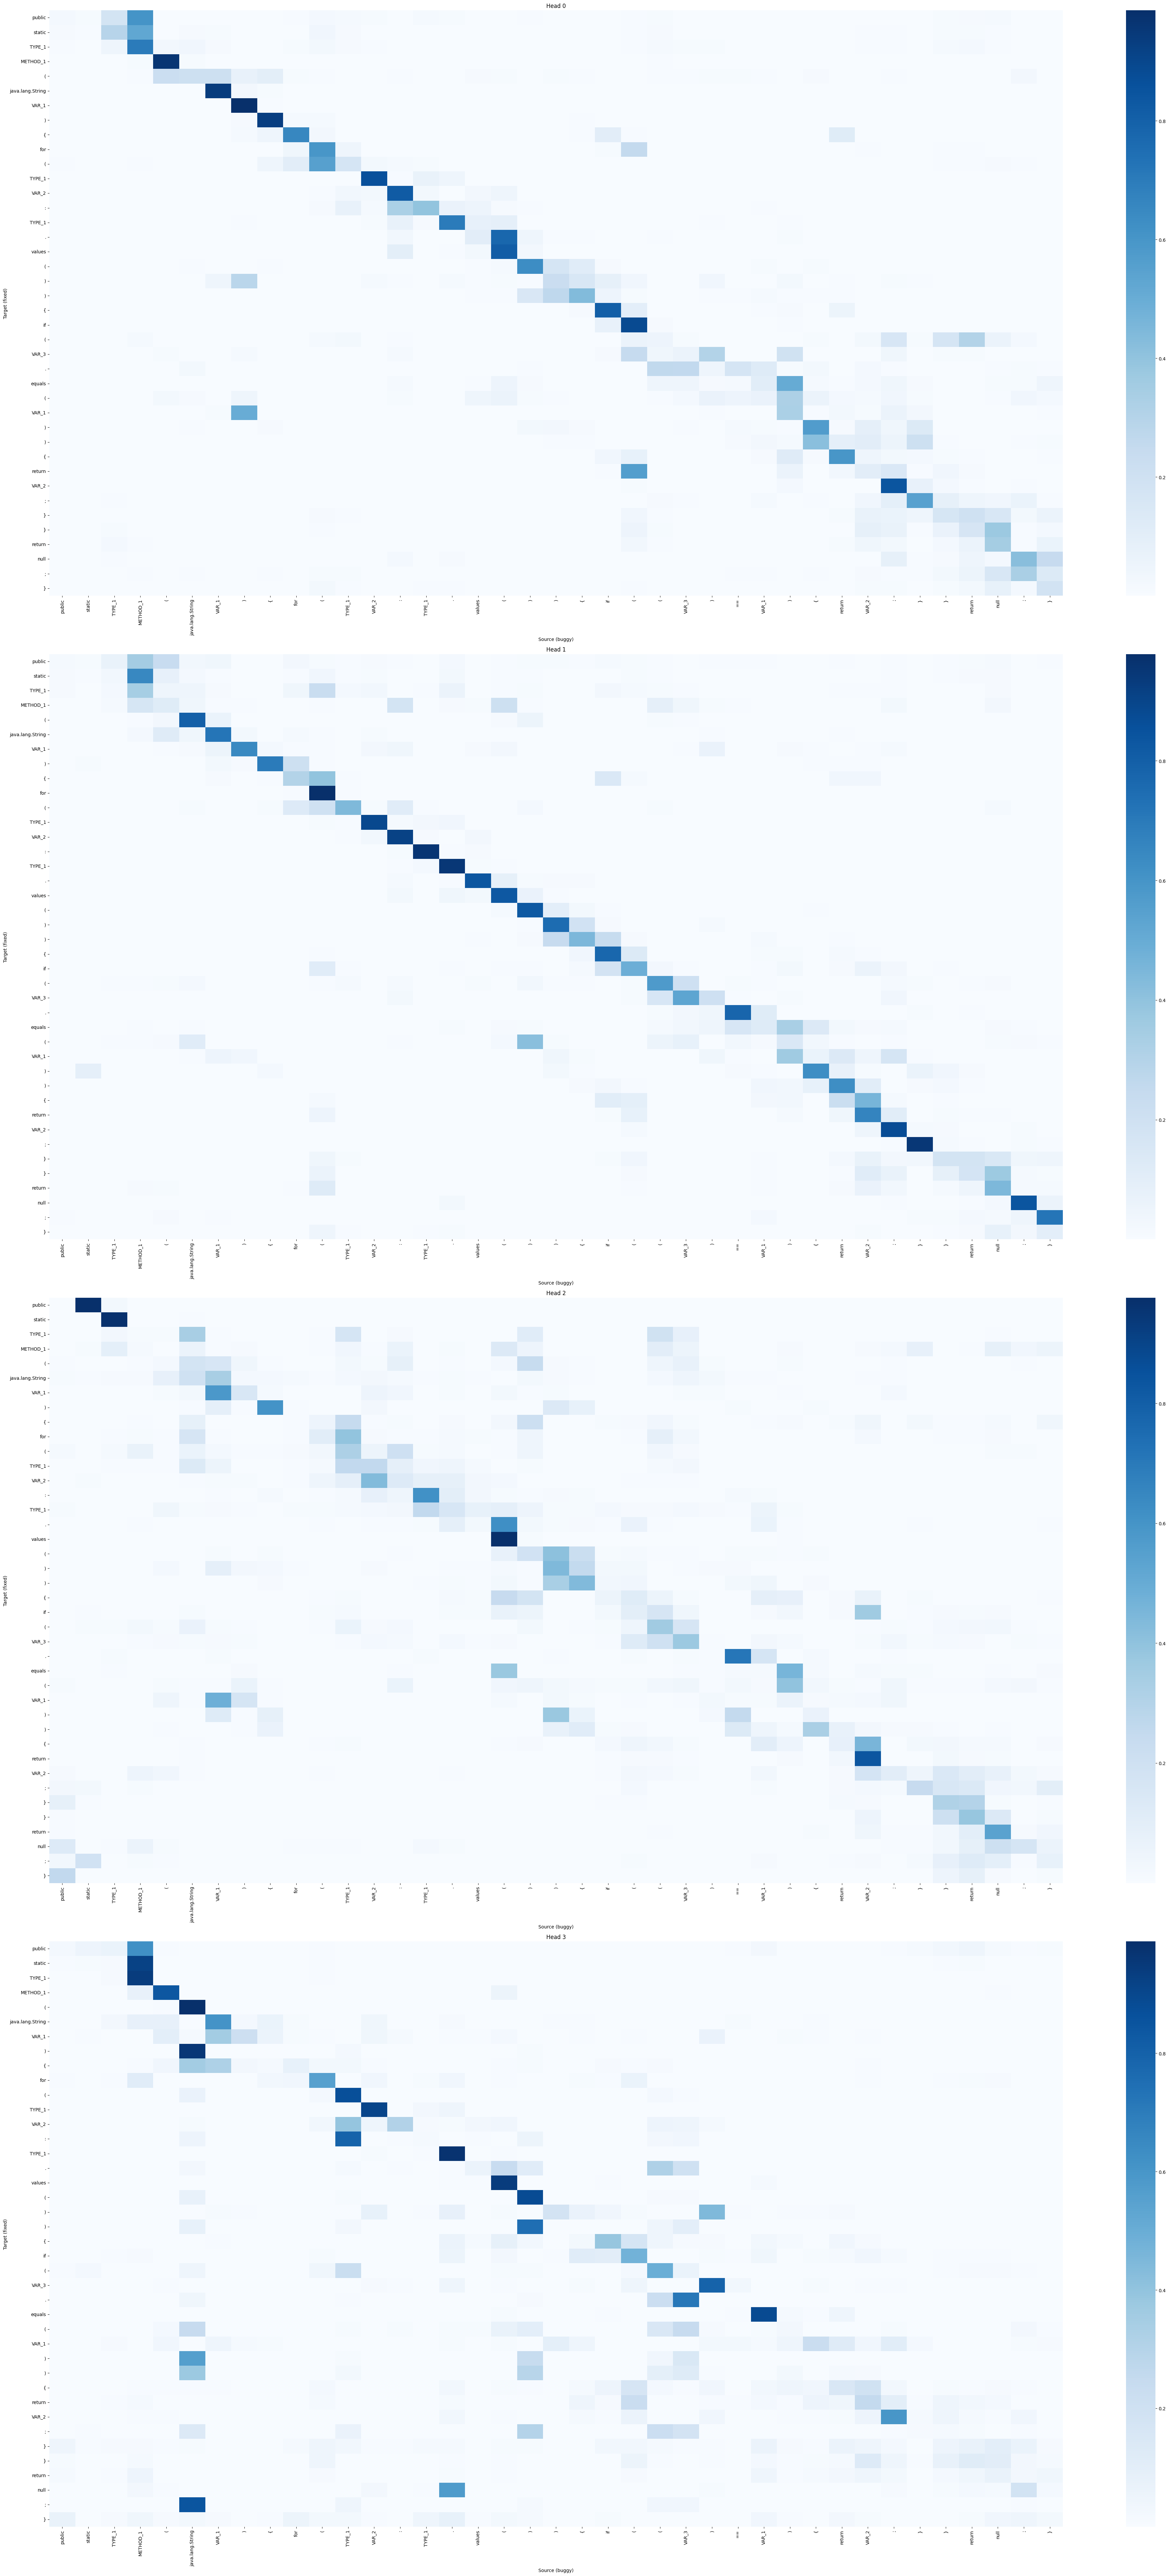

<IPython.core.display.Javascript object>

In [81]:
def viz_cross_attention(model, ex, layer=-1):
    model.eval()
    l = len(ex['buggy'].split())
    src = torch.tensor([encode(ex['buggy'])], dtype=torch.long, device=device)
    tgt = torch.tensor([encode(ex['fixed'])], dtype=torch.long, device=device)
    with torch.no_grad():
        enc, mask = model.encode(src)
        _, cws = model.decode(tgt, enc, mask)    # cws: list[(1,H,T,S)]
    src_toks = ex['buggy'].split()
    tgt_toks = ex['fixed'].split()
    cw = cws[layer][0].cpu().numpy()[:,:len(tgt_toks), :len(src_toks)]

    n_heads = cw.shape[0]
    fig,ax = plt.subplots(n_heads,1, figsize=(len(tgt_toks), 2*len(src_toks)))
    for h in range(n_heads):
        sns.heatmap(cw[h], xticklabels=src_toks, yticklabels=tgt_toks, cmap='Blues', ax=ax[h])
        ax[h].set_title(f"Head {h}")
        ax[h].set_xlabel("Source (buggy)")
        ax[h].set_ylabel("Target (fixed)")
    plt.tight_layout()
    plt.show()

    head_view(cross_attention=[w[:, :, :l, :l].cpu() for w in cws],decoder_tokens=tgt_toks[:l],encoder_tokens=src_toks[:l])

ex = test_df.sample(1).iloc[0]
src = torch.tensor([encode(ex['buggy'])], dtype=torch.long, device=device)
print(f'buggy: {ex["buggy"]}')
print(f'fixed: {ex["fixed"]}')
print(f'pred: {decode(greedy_decode(transformer, src))}')
viz_cross_attention(transformer, ex, -1)